How are In-Demand Skills Trending?

To find how skills are trending in 2023 for Data Analysts, I filtered data analyst positions and grouped the skills by the month of the job postings. This got me the top 5 skills of data analysts by month, showing how popular skills were throughout 2023.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()


In [14]:
df_raw = df.copy()
median_average = df_raw[['salary_year_avg','salary_hour_avg']].median()
df_raw[['salary_year_avg','salary_hour_avg']] = df_raw[['salary_year_avg','salary_hour_avg']].fillna(median_average)
df_raw

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,115000.0,45.98,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,115000.0,45.98,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,115000.0,45.98,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,115000.0,45.98,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,115000.0,45.98,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,115000.0,45.98,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,115000.0,45.98,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,115000.0,45.98,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,115000.0,45.98,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [15]:
df_cleaned = df_raw.dropna(subset = ['job_skills'])
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 668704 entries, 1 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        668704 non-null  object 
 1   job_title              668704 non-null  object 
 2   job_location           667775 non-null  object 
 3   job_via                668696 non-null  object 
 4   job_schedule_type      658121 non-null  object 
 5   job_work_from_home     668704 non-null  bool   
 6   search_location        668704 non-null  object 
 7   job_posted_date        668704 non-null  object 
 8   job_no_degree_mention  668704 non-null  bool   
 9   job_health_insurance   668704 non-null  bool   
 10  job_country            668665 non-null  object 
 11  salary_rate            29801 non-null   object 
 12  salary_year_avg        668704 non-null  float64
 13  salary_hour_avg        668704 non-null  float64
 14  company_name           668696 non-nu

In [16]:
df_cleaned['job_skills'] = df_cleaned['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df_cleaned

<ipython-input-16-3a11f88f7fdc>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['job_skills'] = df_cleaned['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,115000.0,45.98,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,115000.0,45.98,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,115000.0,45.98,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,115000.0,45.98,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,None,115000.0,45.98,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,115000.0,45.98,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,115000.0,45.98,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,115000.0,45.98,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,115000.0,45.98,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [17]:
df_exploded = df_cleaned.explode('job_skills')
df_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,115000.0,45.98,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,115000.0,45.98,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,115000.0,45.98,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,115000.0,45.98,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,115000.0,45.98,Hewlett Packard Enterprise,power bi,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,115000.0,45.98,Capital One,kafka,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,115000.0,45.98,Capital One,kubernetes,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,115000.0,45.98,Capital One,docker,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}"


In [18]:
df_india = df_exploded[df_exploded['job_country'] == 'India']
df_india

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,powershell,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,python,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,sql,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,mysql,"{'cloud': ['databricks', 'azure'], 'databases'..."
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,sql server,"{'cloud': ['databricks', 'azure'], 'databases'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785712,Data Engineer,India - Collections Analyst II,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,Varite India Private Limited,flow,"{'analyst_tools': ['excel'], 'other': ['flow']}"
785716,Software Engineer,Application Support Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,CompuGroup Medical,c#,"{'programming': ['c#', 'sql']}"
785716,Software Engineer,Application Support Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,CompuGroup Medical,sql,"{'programming': ['c#', 'sql']}"
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}"


In [19]:
df_india['month'] = pd.to_datetime(df_india['job_posted_date']).dt.strftime('%b')
df_india

<ipython-input-19-d9f60b513e68>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_india['month'] = pd.to_datetime(df_india['job_posted_date']).dt.strftime('%b')


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,month
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,powershell,"{'cloud': ['databricks', 'azure'], 'databases'...",Jun
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,python,"{'cloud': ['databricks', 'azure'], 'databases'...",Jun
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,sql,"{'cloud': ['databricks', 'azure'], 'databases'...",Jun
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,mysql,"{'cloud': ['databricks', 'azure'], 'databases'...",Jun
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,115000.0,45.98,Hexaware Technologies,sql server,"{'cloud': ['databricks', 'azure'], 'databases'...",Jun
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785712,Data Engineer,India - Collections Analyst II,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,Varite India Private Limited,flow,"{'analyst_tools': ['excel'], 'other': ['flow']}",Mar
785716,Software Engineer,Application Support Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,CompuGroup Medical,c#,"{'programming': ['c#', 'sql']}",Mar
785716,Software Engineer,Application Support Analyst,India,melalui BeBee India,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,CompuGroup Medical,sql,"{'programming': ['c#', 'sql']}",Mar
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,None,115000.0,45.98,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}",Mar


df_cleaned_pivot = df_cleaned.pivot(index = '' )

In [20]:
df_india = df_india[df_india['job_title_short']=='Data Analyst']
df_india_month = df_india.groupby(['month','job_skills']).size().reset_index(name = 'skill_count')
df_india_month

,month,job_skills,skill_count
0,Apr,airflow,8
1,Apr,alteryx,8
2,Apr,angular,1
3,Apr,arch,4
4,Apr,asp.net,1
...,...,...,...
1332,Sep,vmware,2
1333,Sep,windows,2
1334,Sep,word,28
1335,Sep,yarn,1


In [21]:
df_total_jobs_india = df_india[['month']].value_counts().reset_index(name = 'count')
df_total_jobs_india

,month,count
0,Nov,2500
1,Aug,2315
2,Sep,2277
3,Jan,2232
4,Dec,2153
5,Oct,1904
6,Jul,1744
7,Mar,1665
8,Feb,1560
9,Apr,1544


In [22]:
df_india_merge = pd.merge(df_india_month, df_total_jobs_india, on ="month",how = 'left')
df_india_merge['perc_skills'] = (df_india_merge['skill_count']/df_india_merge['count'])*100
df_india_merge

,month,job_skills,skill_count,count,perc_skills
0,Apr,airflow,8,1544,0.518135
1,Apr,alteryx,8,1544,0.518135
2,Apr,angular,1,1544,0.064767
3,Apr,arch,4,1544,0.259067
4,Apr,asp.net,1,1544,0.064767
...,...,...,...,...,...
1332,Sep,vmware,2,2277,0.087835
1333,Sep,windows,2,2277,0.087835
1334,Sep,word,28,2277,1.229688
1335,Sep,yarn,1,2277,0.043917


In [23]:
df_india_merge_pivot = df_india_merge.pivot_table(index = 'month',columns = 'job_skills', values = 'perc_skills',aggfunc = 'mean').fillna(0)
df_india_merge_pivot
month_order = [
    'Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'
]
df_india_merge_pivot = df_india_merge_pivot.reindex(month_order)
df_india_merge_pivot

job_skills,airflow,alteryx,angular,ansible,arch,asana,asp.net,assembly,atlassian,aurora,...,vue.js,watson,webex,windows,wire,word,workfront,wrike,yarn,zoom
month,,,,,,,,,,,,,,,,,,,,,
Jan,0.134409,0.940860,0.044803,0.000000,0.000000,0.000000,0.044803,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.044803,0.179211,0.044803,1.657706,0.000000,0.00,0.000000,0.134409
Feb,0.448718,1.089744,0.064103,0.000000,0.128205,0.000000,0.000000,0.064103,0.000000,0.064103,...,0.000000,0.064103,0.064103,0.320513,0.000000,1.538462,0.000000,0.00,0.000000,0.000000
Mar,0.360360,0.960961,0.120120,0.060060,0.000000,0.000000,0.000000,0.060060,0.060060,0.000000,...,0.000000,0.000000,0.000000,0.300300,0.000000,1.621622,0.000000,0.00,0.000000,0.120120
Apr,0.518135,0.518135,0.064767,0.000000,0.259067,0.000000,0.064767,0.129534,0.000000,0.000000,...,0.000000,0.000000,0.064767,0.259067,0.000000,1.748705,0.000000,0.00,0.000000,0.064767
May,0.485437,1.262136,0.000000,0.000000,0.097087,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.485437,0.000000,1.262136,0.000000,0.00,0.000000,0.000000
Jun,0.354108,1.558074,0.070822,0.000000,0.000000,0.000000,0.070822,0.000000,0.000000,0.070822,...,0.000000,0.000000,0.000000,0.070822,0.000000,0.849858,0.070822,0.00,0.000000,0.070822
Jul,0.573394,0.745413,0.114679,0.000000,0.057339,0.000000,0.000000,0.000000,0.000000,0.057339,...,0.000000,0.229358,0.000000,0.229358,0.000000,1.261468,0.000000,0.00,0.000000,0.114679
Aug,0.820734,1.079914,0.086393,0.000000,0.000000,0.000000,0.000000,0.000000,0.086393,0.000000,...,0.000000,0.043197,0.000000,0.172786,0.000000,1.339093,0.000000,0.00,0.043197,0.043197
Sep,0.175670,0.614844,0.000000,0.000000,0.000000,0.087835,0.000000,0.000000,0.043917,0.219587,...,0.000000,0.000000,0.000000,0.087835,0.000000,1.229688,0.000000,0.00,0.043917,0.087835


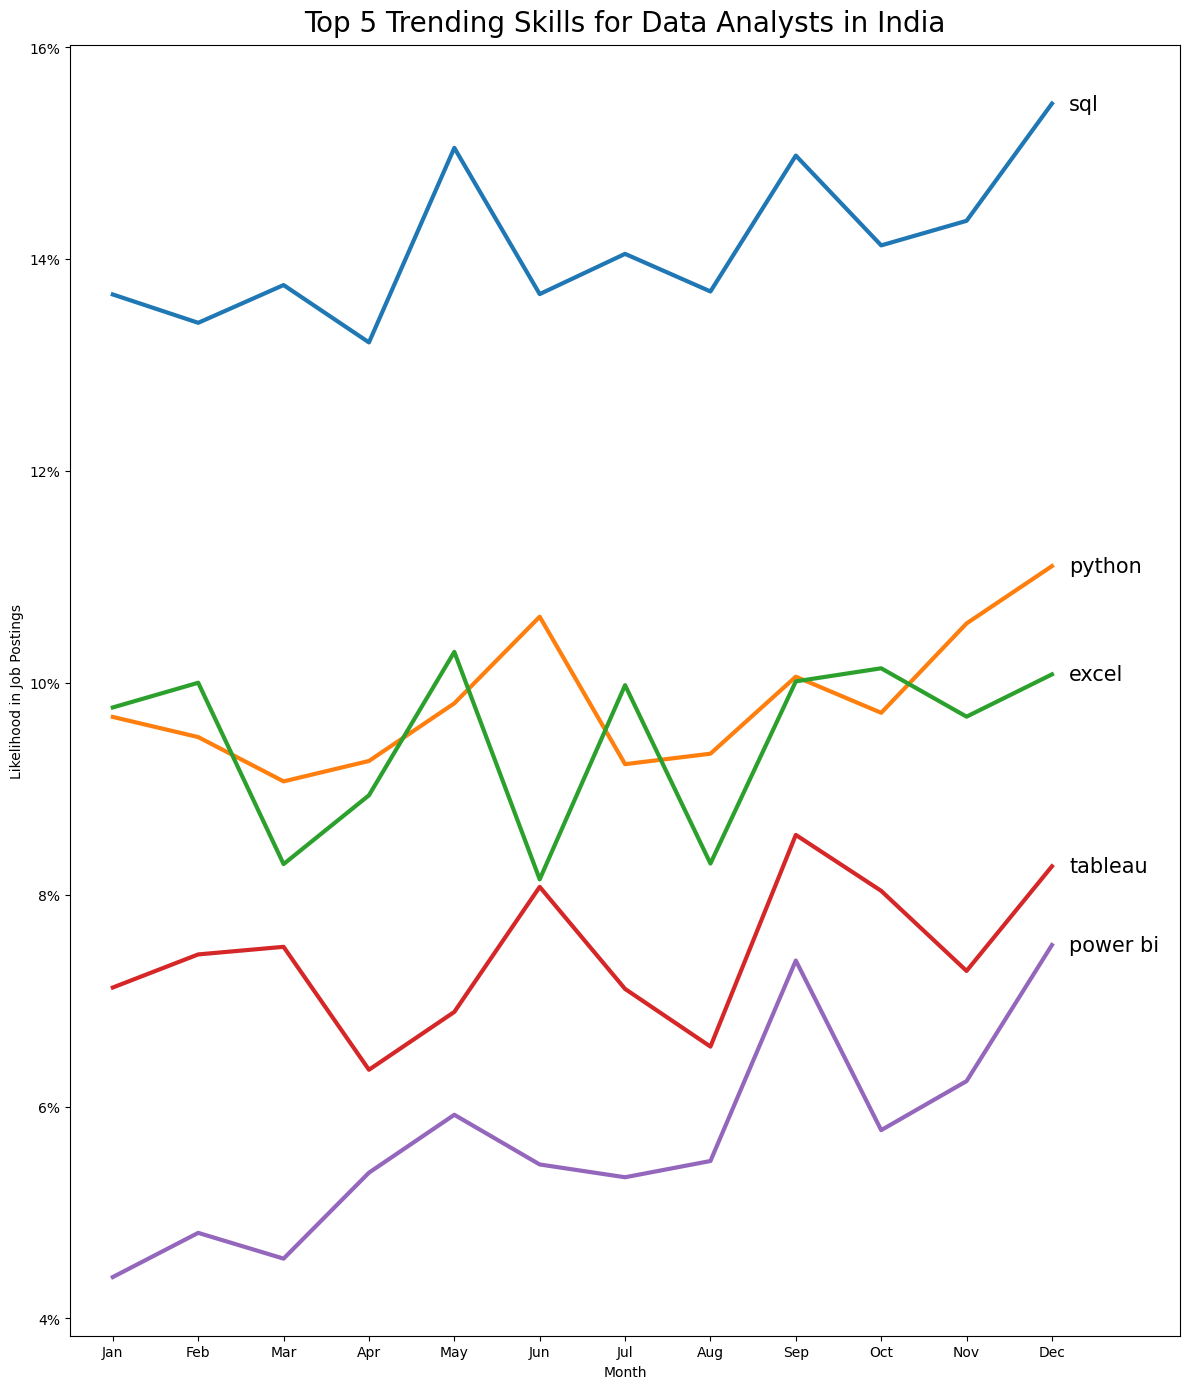

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.style.use('default')

df_india_top8 = df_india_merge.groupby('job_skills')['perc_skills'].sum().sort_values(ascending=False).head(5).index.tolist()
df_india_skills_line = df_india_merge_pivot[df_india_top8]

fig, ax = plt.subplots(1, 1, figsize=(12, 14), facecolor='white')
ax.set_facecolor('white')

df_india_skills_line.plot(kind='line', ax=ax, linewidth=3)

ax.set_xticks(range(len(df_india_skills_line.index)))
ax.set_xticklabels(df_india_skills_line.index)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

ax.set_title("Top 5 Trending Skills for Data Analysts in India", fontsize=20, pad=10, color='black')
ax.set_ylabel("Likelihood in Job Postings", color='black')
ax.set_xlabel("Month", color='black')
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_color('black')
    
plt.legend().remove()

ax.set_xlim(-0.5, 12.5)

for i in range(5):
    skill_name = df_india_skills_line.columns[i]
    final_val = df_india_skills_line[skill_name].iloc[-1]
    ax.text(x=11.2, y=final_val, s=f"{skill_name}", va='center', ha='left', fontsize=15, color='black')

plt.tight_layout()
plt.savefig('my_plot.png', facecolor='white', transparent=False, bbox_inches='tight', dpi=300)
plt.show()

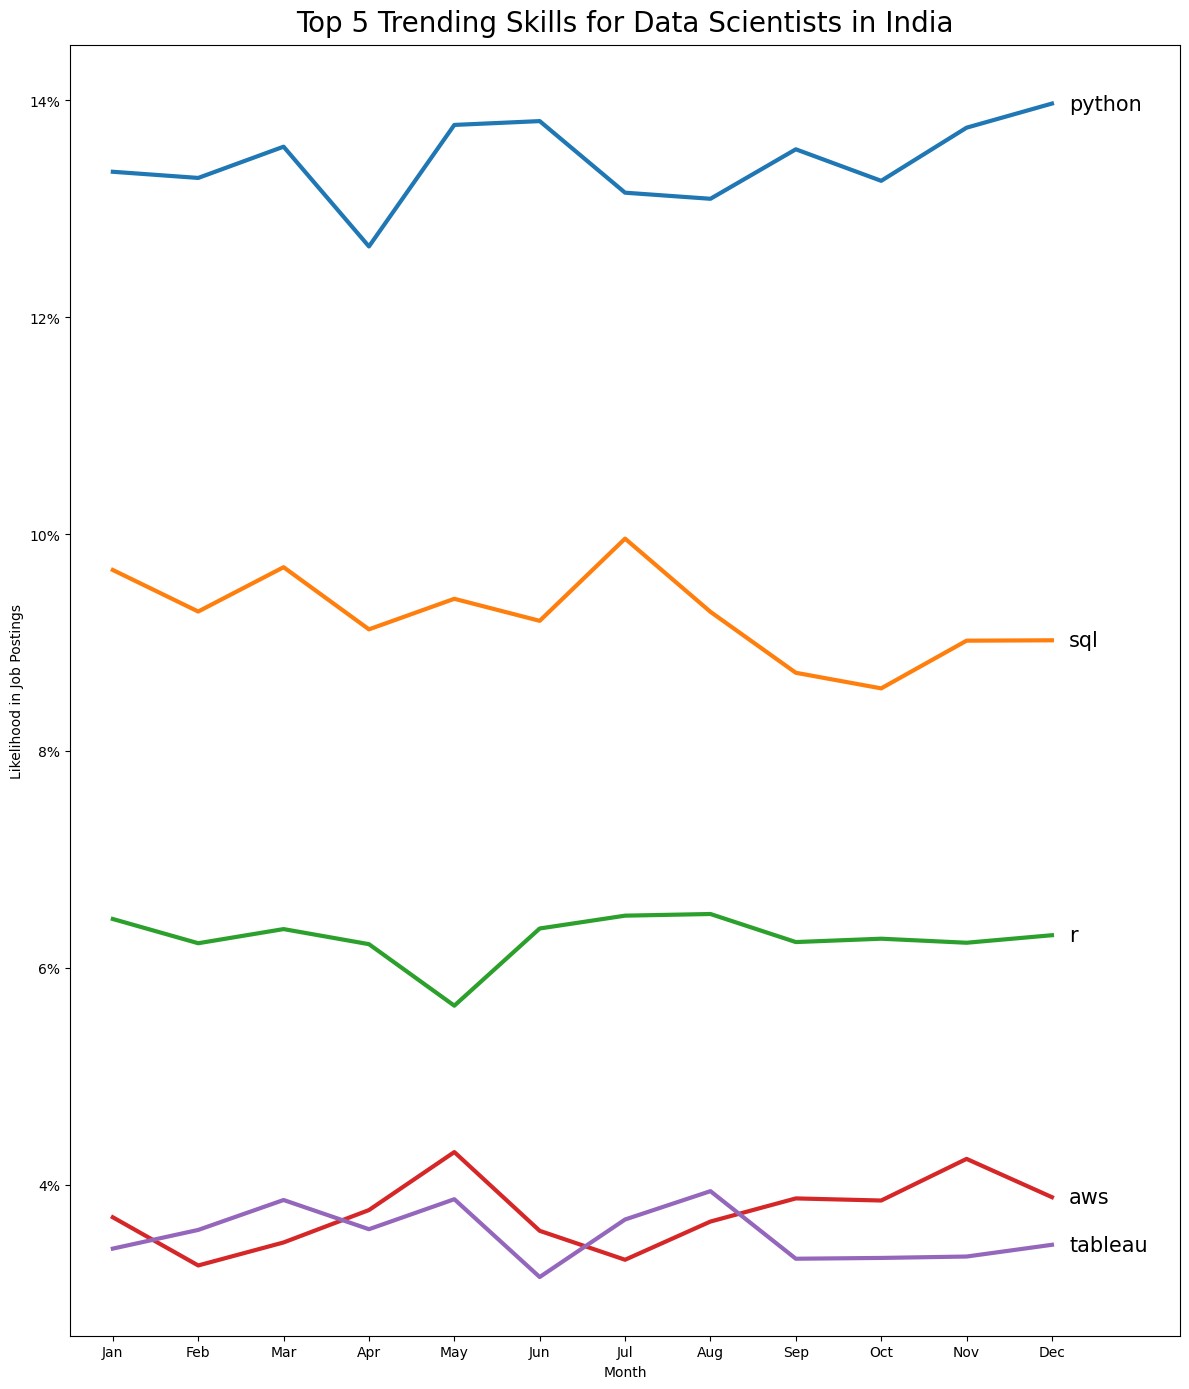

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import ast
import seaborn as sns
from datasets import load_dataset

# 1. Load Dataset
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# 2. Data Cleaning & Preparation
df_raw = df.copy()
median_average = df_raw[['salary_year_avg', 'salary_hour_avg']].median()
df_raw[['salary_year_avg', 'salary_hour_avg']] = df_raw[['salary_year_avg', 'salary_hour_avg']].fillna(median_average)

df_cleaned = df_raw.dropna(subset=['job_skills']).copy()
df_cleaned['job_skills'] = df_cleaned['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# 3. Explode Skills Array
df_exploded = df_cleaned.explode('job_skills')

# 4. Filter for India & Extract Month
df_india_ds = df_exploded[df_exploded['job_country'] == 'India'].copy()
df_india_ds['month'] = pd.to_datetime(df_india_ds['job_posted_date']).dt.strftime('%b')

# 5. Filter for Data Scientist Roles
df_india_ds = df_india_ds[df_india_ds['job_title_short'] == 'Data Scientist']

# 6. Group Skills by Month
df_india_month_ds = df_india_ds.groupby(['month', 'job_skills']).size().reset_index(name='skill_count')

# 7. Calculate Total Job Count per Month
df_total_jobs_india_ds = df_india_ds[['month']].value_counts().reset_index(name='count')

# 8. Merge and Calculate Skill Percentages
df_india_merge_ds = pd.merge(df_india_month_ds, df_total_jobs_india_ds, on='month', how='left')
df_india_merge_ds['perc_skills'] = (df_india_merge_ds['skill_count'] / df_india_merge_ds['count']) * 100

# 9. Pivot Table & Order Months
df_india_merge_pivot_ds = df_india_merge_ds.pivot_table(
    index='month', 
    columns='job_skills', 
    values='perc_skills', 
    aggfunc='mean'
).fillna(0)

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_india_merge_pivot_ds = df_india_merge_pivot_ds.reindex(month_order)

# 10. Extract Top 5 Skills
df_india_top5_ds = (
    df_india_merge_ds.groupby('job_skills')['perc_skills']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
df_india_skills_line_ds = df_india_merge_pivot_ds[df_india_top5_ds]

# 11. Plotting Trend Lines
fig, ax = plt.subplots(1, 1, figsize=(12, 14))
df_india_skills_line_ds.plot(kind='line', ax=ax, linewidth=3)

ax.set_xticks(range(len(df_india_skills_line_ds.index)))
ax.set_xticklabels(df_india_skills_line_ds.index)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title("Top 5 Trending Skills for Data Scientists in India", fontsize=20, pad=10)
ax.set_ylabel("Likelihood in Job Postings")
ax.set_xlabel("Month")
plt.legend().remove()


ax.set_xlim(-0.5, 12.5)

for i in range(5):
    skill_name = df_india_skills_line_ds.columns[i]
    final_val = df_india_skills_line_ds[skill_name].iloc[-1]
    ax.text(x=11.2, y=final_val, s=f"{skill_name}", va='center', ha='left', fontsize=15)

plt.tight_layout()
plt.savefig('my_plot_ds.png', facecolor='white', transparent=False, bbox_inches='tight', dpi=300)
plt.show()